### **1. Cargar la base de datos. Identifique los tipos de datos que se encuentran en la base, realice estadísticas descriptivas sobre las variables importantes (distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

**R**: Se cargó la base de datos panel_eps.csv, la cual contiene datos en formato panel, identificando a cada individuo por su folio_n20 y la ronda de la encuesta con time. Se inspeccionaron tipos de variables, valores nulos y presencia de outliers mediante análisis descriptivo y visualizaciones como mapas de calor y boxplots.

Primero, se eliminaron columnas completamente vacías (fondoa, fondob, fondoc, fondod, fondoe) y variables redundantes como selfemp. Luego, se completaron valores faltantes de la variable sistema utilizando reglas basadas en cotización, activos previsionales, informalidad y situación laboral.

La variable expectancy fue depurada: se transformaron valores mayores a 150 en NaN y se imputó con el próximo valor que habia respondido la persona, en caso de no tener, se rellenó con el valor anterior. Para las variables laborales (size, occupation, wage, hours, informal, publicemp) se imputó con ceros en los casos de inactividad, se aplicó lo mismo para region

Las variables de salud (illness, cronica, nocronica, mental) se imputaron con relleno hacia adelante dentro de cada individuo (bfill). La variable exp se imputó con cero para los casos faltantes, ya que su ausencia se concentraba en personas inactivas. Children se imputó con cero. Assets fue interpolado de forma lineal por individuo, y luego se usó para completar los valores faltantes originales. Region fue completado hacia adelante y hacia atrás por cada persona (ffill y bfill).

Se eliminaron los valores extremos (5% superior) en horas trabajadas (hours) y se evaluaron límites extremos en la variable expectancy, aunque no se aplicó recorte final en esta última. Se crearon interacciones como edu_age, edu_illness, etc, pero ninguna resultó significativa. Además, de variables dummificadas para status, situation, region, años y children (agrupado).

Finalmente, se reorganizó el dataset en formato panel con índices folio_n20 y time, preparando la estructura para la estimación de modelos como efectos fijos, efectos aleatorios y CRE.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
from sklearn.preprocessing import StandardScaler
import numpy.linalg as la
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [37]:
df = pd.read_csv("panel_eps.csv", delimiter = "," ,header = 0)
df = df.rename(columns={'edad': 'age'})

# Ordenar por persona (folio_n20) y ronda (time)
df = df.sort_values(['time']).reset_index(drop=True)
df

,folio_n20,year,time,age,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124816357605,2,1,1982,0.0,4.0,7.0,1.0,1,1.0,...,NaN,NaN,NaN,NaN,11,90.0,NaN,NaN,NaN,NaN
1,124602784280,2,1,1983,1.0,2.0,3.0,1.0,0,0.0,...,NaN,NaN,NaN,NaN,22,75.0,NaN,NaN,NaN,NaN
2,124805811904,2,1,1982,1.0,18.0,7.0,1.0,1,1.0,...,NaN,NaN,NaN,NaN,20,70.0,NaN,NaN,NaN,NaN
3,124805815809,2,1,1982,0.0,4.0,10.0,2.0,1,1.0,...,NaN,NaN,NaN,NaN,7,60.0,NaN,NaN,NaN,NaN
4,124602772565,2,1,66,0.0,9.0,7.0,1.0,0,0.0,...,NaN,NaN,NaN,NaN,0,90.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,124608728613,15,6,1995,1.0,17.0,12.0,1.0,0,0.0,...,NaN,NaN,NaN,NaN,34,NaN,0.0,0.0,0.0,0.0
96842,124793376467,15,6,1995,0.0,NaN,13.0,5.0,0,0.0,...,NaN,NaN,NaN,NaN,22,NaN,1.0,0.0,0.0,0.0
96843,124793350765,15,6,1995,1.0,8.0,13.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,26,NaN,0.0,0.0,0.0,0.0
96844,124793495037,15,6,1995,0.0,7.0,13.0,5.0,1,2.0,...,NaN,NaN,NaN,NaN,21,NaN,1.0,0.0,0.0,1.0


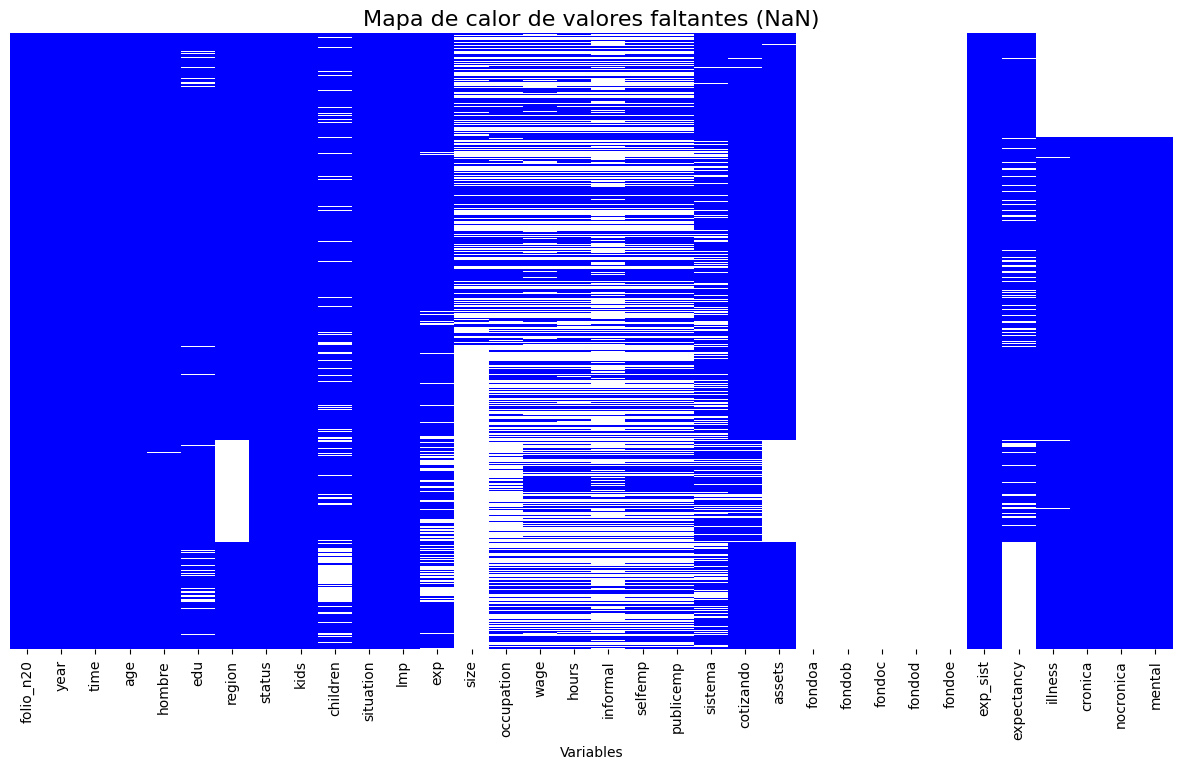

In [38]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), 
            cbar=False, 
            cmap=sns.color_palette(["blue" , "white"]), 
            yticklabels=False)
plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.show()

In [39]:
# Lista de columnas a eliminar
columnas_a_eliminar = ['selfemp', 'fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe']

# Eliminación de columnas
df = df.drop(columns=columnas_a_eliminar)

In [40]:
# Regla 1: Cotiza en el sistema (aunque sea informal)
df.loc[(df['sistema'].isna()) & (df['cotizando'] == 1), 'sistema'] = 1

# Regla 2: Tiene activos en el sistema
df.loc[(df['sistema'].isna()) & (df['assets'] > 0), 'sistema'] = 1

# Regla 3: Inactivo ']. fuera del sistema
df.loc[(df['sistema'].isna()) & (df['situation'] == 4), 'sistema'] = 0

# Regla 4: Informal y no cotiza y sin activos → fuera del sistema
df.loc[
    (df['sistema'].isna()) &
    (df['informal'] == 1) &
    (df['cotizando'] != 1) &
    (df['assets'].isna() | (df['assets'] == 0)),
    'sistema'
] = 0

In [41]:
# Lista de columnas a rellenar con 0
columnas_a_rellenar = ['size', 'occupation', 'wage', 'hours', 'informal', 'publicemp']

# Rellenar con 0 en el DataFrame de inactivos
df[columnas_a_rellenar] = df[columnas_a_rellenar].fillna(0)

In [42]:
salud_vars = ['illness', 'cronica', 'nocronica', 'mental']

# Rellenar hacia adelante (bfill: rellenar NaN con valor siguiente dentro de cada persona)
df[salud_vars] = df.groupby('folio_n20')[salud_vars].bfill()

In [43]:
# # Porcentaje de NaNs por columna
# porcentaje_nans = df.isnull().mean().sort_values(ascending=False) * 100
# print(porcentaje_nans[porcentaje_nans > 0])  # Solo las que tienen NaNs

In [44]:
df[df['exp'].isnull()]['situation'].value_counts(normalize=True)

situation
3    0.563413
4    0.348501
2    0.081406
1    0.006679
Name: proportion, dtype: float64

In [45]:
df['exp'] = df['exp'].fillna(0)

In [46]:
# print("\nDistribución por ronda (time):")
# print(df[df['expectancy'].isnull()]['time'].value_counts(normalize=True))

# print("\nDistribución por año (year):")
# print(df[df['expectancy'].isnull()]['year'].value_counts(normalize=True))

In [47]:
df[df['expectancy'].isnull()]['situation'].value_counts(normalize=True)

situation
3    0.497685
4    0.429023
2    0.070318
1    0.002974
Name: proportion, dtype: float64

EXPECTANCY LO RELLENAMOS CON EL ULTIMO VALOR PUESTO O CON LA MEDIA

In [48]:
# Convertir valores de expectancy > 150 en NaN
df.loc[df['expectancy'] > 150, 'expectancy'] = np.nan

In [49]:
#Rellenar hacia adelante (ffill) por persona
df['expectancy'] = df.groupby('folio_n20')['expectancy'].ffill().bfill()


In [50]:
df['children'] = df['children'].fillna(0)

In [51]:
# Ordenar por ID y ronda
df = df.sort_values(by=['folio_n20', 'time'])

# Interpolación lineal de 'assets' dentro de cada individuo
df['assets_interp'] = df.groupby('folio_n20')['assets'].transform(lambda x: x.interpolate(method='linear'))

# Rellenar los NaN originales con los interpolados
df['assets'] = df['assets'].fillna(df['assets_interp'])

# Eliminar la columna temporal
df = df.drop(columns='assets_interp')

In [52]:
# Rellenar región hacia adelante y atrás por individuo
df['region'] = df.groupby('folio_n20')['region'].ffill().bfill()

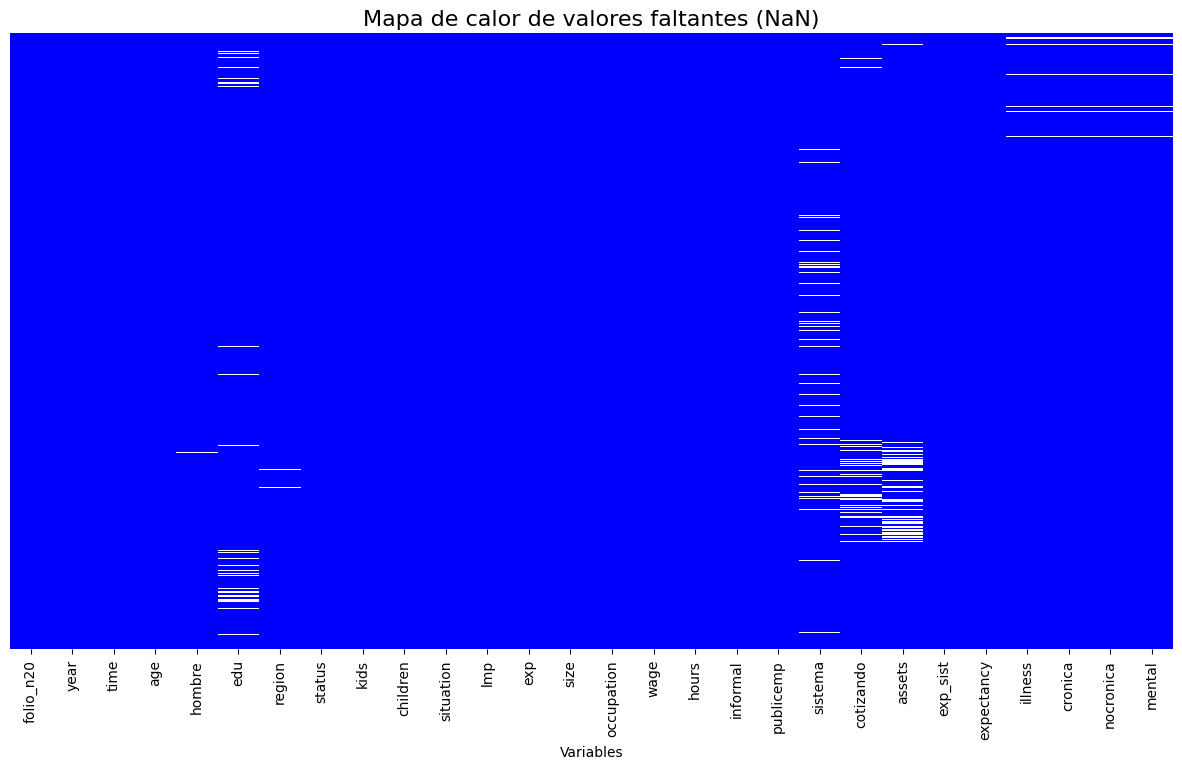

In [53]:
df = df.sort_values(['time']).reset_index(drop=True)
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), 
            cbar=False, 
            cmap=sns.color_palette(["blue" , "white"]), 
            yticklabels=False)

plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.show()

In [54]:
df_try = df.copy()
df.dropna(inplace=True)  # Esto sí modifica df

In [55]:
# Eliminar el 5% superior de 'hours'
q95_hours = df['hours'].quantile(0.95)
df = df[df['hours'] <= q95_hours]

# Eliminar el 1% superior e inferior de 'expectancy'
#q01_expectancy = df['expectancy'].quantile(0.01)
#q99_expectancy = df['expectancy'].quantile(0.99)
# df = df[(df['expectancy'] >= q01_expectancy) & (df['expectancy'] <= q99_expectancy)]

In [56]:
# columns_to_plot = [
#     'age', 'edu', 'children', 'exp', 'size', 'occupation',
#     'wage', 'hours', 'assets', 'exp_sist', 'expectancy'
# ]

# # Filtrar columnas que existan y sean numéricas
# numeric_columns = [col for col in columns_to_plot if col in df.columns and np.issubdtype(df[col].dtype, np.number)]

# # Crear los boxplots
# fig, axes = plt.subplots(nrows=len(numeric_columns), ncols=1, figsize=(10, 5 * len(numeric_columns)))

# for i, col in enumerate(numeric_columns):
#     sns.boxplot(data=df, x=col, ax=axes[i])
#     axes[i].set_title(f'Diagrama de caja: {col}')
#     axes[i].set_xlabel(col)

# plt.tight_layout()
# plt.show()

In [57]:
# Correlación con 'expectancy'
# df.corr(numeric_only=True)['expectancy'].sort_values(ascending=False)

In [58]:
# # Estandarizamos las de $
# scaler = StandardScaler()

# df[['assets', 'wage']] = scaler.fit_transform(df[['assets', 'wage']])

In [59]:
df_panel = df.set_index(['folio_n20', 'time'])

In [60]:
def clasificar_hijos(x):
    if x == 0:
        return 'sin_hijos'
    elif 1 <= x <= 3:
        return 'pocos_hijos'
    else:
        return 'muchos_hijos'

df_panel['children'] = df_panel['children'].apply(clasificar_hijos)

In [61]:
df_panel['edu_age'] = df_panel['edu'] * df_panel['age']
df_panel['edu_illness'] = df_panel['edu'] * df_panel['illness']
df_panel['cotiz_sistema'] = df_panel['cotizando'] * df_panel['sistema']

In [62]:
status_dummies = pd.get_dummies(df_panel['status'], prefix='status', drop_first=True).astype(int)
situation_dummies = pd.get_dummies(df_panel['situation'], prefix='situation', drop_first=True).astype(int)
region_dummies = pd.get_dummies(df_panel['region'], prefix='region', drop_first=True).astype(int)
year_dummies = pd.get_dummies(df_panel['year'], prefix='year', drop_first=True).astype(int)
#region_dummies = region_dummies[['region_2.0', 'region_8.0', 'region_9.0', 'region_11.0', 'region_15.0']]

children_dummies = pd.get_dummies(df_panel['children']).astype(int)
children_dummies = children_dummies.drop(columns='sin_hijos', errors='ignore')


# Variables continuas y binarias relevantes
vars_continuas = df_panel[['edu', 'exp', 'wage', 'hours', 'assets', 'exp_sist',
                           'cronica', 'nocronica', 'mental',
                           'sistema', 'cotizando', 'publicemp', 'informal',
                           'edu_age', 'cotiz_sistema']]

### PREGUNTA 2: Ejecute un modelo Pooled OLS para estimar la relacion entre los años de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R:** En el modelo Pooled OLS se incluyeron variables socioeconómicas y de salud relevantes como experiencia laboral, ingreso, horas trabajadas, activos en el sistema de pensiones, condiciones de salud (crónica, no crónica, mental), tipo de empleo, estado civil, situación laboral, número de hijos y región. Estas se seleccionaron por su relevancia teórica y estadística, omitiendo aquellas redundantes o con alta colinealidad.

Los resultados muestran que los años de educación están significativamente asociados a la expectativa de vida en esta especificación (p = 0.028 aprox < 0.05 y t = -2.2 <-1.96). Además, variables como la experiencia laboral, el ingreso, y los activos previsionales presentan una relación positiva significativa, mientras que condiciones de salud, trabajo informal, empleo público y ciertas regiones tienen efectos negativos relevantes. Por ejemplo, tener una enfermedad mental se asocia con una reducción de más de 2 puntos en la expectativa de vida reportada. De forma similar, vivir en regiones como la 8 o 15 también se asocia negativamente. En contraste, estar viudo se asocia con una expectativa de vida más alta, lo que podría reflejar sesgos de selección. Tamvién se puede observar que, al pasar los años (rondas) podemos ver que claramente crece la expectativa de vida.

Por otro lado, el modelo explica alrededor del 7.17% de la variación total (R² = 0.0717 aprox).

In [63]:
# Combinar todo
X = pd.concat([vars_continuas, status_dummies, situation_dummies, children_dummies, region_dummies, year_dummies], axis=1)
# Variable dependiente
y = df_panel['expectancy']
X = sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0717
Estimator:                   PanelOLS   R-squared (Between):              0.1442
No. Observations:               77267   R-squared (Within):               0.0154
Date:               mar, may. 20 2025   R-squared (Overall):              0.0717
Time:                        19:23:15   Log-likelihood                -2.883e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      138.68
Entities:                       23158   P-value                           0.0000
Avg Obs:                       3.3365   Distribution:                F(43,77223)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             138.68
                            

# PREGUNTA 3

**R:** El modelo de efectos fijos permite controlar por heterogeneidad no observada que es constante en el tiempo a nivel individual, lo cual mejora la estimación del efecto causal de la educación sobre la expectativa de vida. Para ello, se utilizó la misma especificación que en el modelo agrupado, así como las mismas variables. 
En este caso, los años de educación no resultaron significativos (tiene un p > 0.05 y t < 1.96), lo que sugiere que la educación, al ser una variable relativamente estable, no explica las variaciones en la expectativa de vida a lo largo del tiempo dentro de una misma persona, sino más bien entre personas. En cambio, sí se identificaron efectos positivos de la experiencia laboral (coef. = 0.11 aprox.), los años en el sistema de pensiones, el paso de las rondas mantiene el mismo comportamiento (mayor expectativa de vida) y negativos de condiciones de salud (enfermedades crónicas, no crónicas y mentales). Además, trabajar en el sector público o informal también se asocia negativamente con la expectativa de vida.

El R² dentro del individuo fue de aproximadamente 3.63%. Al eliminar la variación entre personas, el modelo se enfoca exclusivamente en cómo los cambios dentro de cada individuo se relacionan con su expectativa de vida. Este enfoque evidencia que parte importante de la relación entre educación y expectativa de vida podría estar explicada por diferencias entre personas, más que por cambios dentro de cada individuo a lo largo del tiempo.

In [64]:
x = X.copy()
x = sm.add_constant(x)
model = lmp.PanelOLS(y,x, entity_effects=True)
fe = model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0361
Estimator:                   PanelOLS   R-squared (Between):             -0.0030
No. Observations:               77267   R-squared (Within):               0.0361
Date:               mar, may. 20 2025   R-squared (Overall):              0.0098
Time:                        19:23:17   Log-likelihood                -2.537e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      47.113
Entities:                       23158   P-value                           0.0000
Avg Obs:                       3.3365   Distribution:                F(43,54066)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             39.790
                            

### **4. Ejecute un modelo de efectos aleatorios para estimar la misma relación anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.**

**R**: El modelo de efectos aleatorios asume que las diferencias individuales no observadas están distribuidas aleatoriamente y no están correlacionadas con las variables explicativas. Se utilizó la misma especificación de variables que en los modelos anteriores para facilitar la comparación. En este modelo, los años de educación aparecen con un coeficiente negativo y marginalmente significativo , lo que sugiere que, bajo los supuestos del modelo RE, un año adicional de educación se asocia con un decrecimiento de 0.0412 años en la expectativa de vida. Muy similar a los modelos anteriores.

Además, se identificaron patrones coherentes modelos previos: mismo comportamiento al pasar las rondas (un poco mayor en las últimas rondas) la experiencia laboral, el ingreso y los activos en el sistema previsional están positivamente asociados a una mayor expectativa de vida, mientras que las enfermedades, el empleo informal y el trabajo en el sector público presentan efectos negativos significativos. Asimismo, estar casado (referencia) o viudo se relaciona con una mayor expectativa de vida en comparación con otros estados civiles, los cuales muestran asociaciones negativas.

El modelo de efectos aleatorios presenta un R² total de 0.5018, lo que indica que logra explicar una proporción considerable de la variabilidad total en la expectativa de vida, un resultado bastantte más alto que en los otros modelos (no necesariamente mejor)

In [65]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.5018
Estimator:              RandomEffects   R-squared (Between):              0.1451
No. Observations:               77267   R-squared (Within):               0.0268
Date:               mar, may. 20 2025   R-squared (Overall):              0.0660
Time:                        19:23:20   Log-likelihood                -2.688e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1809.1
Entities:                       23158   P-value                           0.0000
Avg Obs:                       3.3365   Distribution:                F(43,77223)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             117.06
                            

# PREGUNTA 5

### **5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados? En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigación y por qué? ¿Qué variables resultaron ser robustas a la especificación?**

**R:** Los resultados sobre el efecto de la educación varían entre modelos. En el modelo agrupado (Pooled OLS), la educación aparece con un efecto negativo y estadísticamente significativo. En el modelo de efectos fijos, al controlar por la heterogeneidad constante entre individuos, este efecto desaparece, lo que sugiere que la relación se explica más por diferencias entre personas que por cambios dentro de ellas. En el modelo de efectos aleatorios, la educación vuelve a mostrar un efecto negativo, aunque marginalmente significativo. 

Estas diferencias se deben a cómo cada modelo trata la variabilidad entre individuos. El modelo de efectos fijos elimina por completo esa variación, enfocándose solo en lo que cambia dentro de la misma persona a lo largo del tiempo. En cambio, el modelo RE la mantiene, pero bajo un supuesto fuerte de exogeneidad. Para evaluar cuál modelo es más confiable, se aplicó el Test de Hausman, que resultó altamente significativo. Esto indica que sí existe correlación entre los efectos individuales y los regresores, por lo que el modelo de efectos aleatorios clásico no es válido.

El modelo más adecuado bajo esta evidencia sería el de efectos fijos, ya que entrega estimaciones más robustas ante el sesgo por omisión de variables inobservadas. Sin embargo, es importante señalar que el modelo CRE (efectos aleatorios correlacionados) también es apropiado, ya que permite capturar tanto la variación entre como dentro del individuo, y su estimación sugiere que el efecto de la educación dentro del individuo es negativo, pero que su promedio no es significativo.

Por otro lado, variables como experiencia laboral, activos en el sistema previsional, salud mental, empleo informal y ciertas regiones mostraron efectos consistentes y significativos en todos los modelos, lo que refuerza su importancia como determinantes robustos de la expectativa de vida.



In [66]:
def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 1981.1890170333913, df = 43, p-value = 0.0


### **6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relación anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. ¿Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?**

**R**: El modelo CRE permitió evaluar si las diferencias entre personas afectan la expectativa de vida de forma sistemática, incorporando los promedios individuales de las variables relevantes. Esto mejora al modelo RE clásico al relajar el supuesto de independencia entre los efectos individuales no observados y los regresores.

Al aplicar este enfoque, se observa que la educación tiene un efecto negativo y significativo dentro del individuo, mientras que su promedio entre personas no lo es. Esto sugiere que las diferencias en educación no explican de forma robusta las variaciones en expectativa de vida entre individuos, y que el efecto estimado podría reflejar problemas de identificación, como colinealidad. Por otro lado, variables como experiencia laboral, salud mental, activos previsionales y empleo informal mantienen efectos consistentes y significativos.

El modelo CRE se ajusta bien a esta base (R² = 0.5045), ya que permite comparar individuos y controlar por heterogeneidad no observada. En este caso, logra modelar adecuadamente el componente no observado, ofreciendo una estimación más completa y confiable que el RE clásico.

In [67]:
vars_CRE = [
    'edu', 'exp', 'wage', 'hours', 'assets', 'exp_sist',
    'cronica', 'nocronica', 'mental', 'sistema', 'cotizando',
    'publicemp', 'informal'
]
Xm = df_panel.groupby('folio_n20')[vars_CRE].transform('mean')
Xm.columns = ['m_' + col for col in Xm.columns]  # Renombrar
X_cre = pd.concat([X, Xm], axis=1)

In [68]:
model = lmp.RandomEffects(y, X_cre)
cre = model.fit(cov_type="robust")
print(cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.5045
Estimator:              RandomEffects   R-squared (Between):              0.1525
No. Observations:               77267   R-squared (Within):               0.0294
Date:               mar, may. 20 2025   R-squared (Overall):              0.0741
Time:                        19:23:23   Log-likelihood                -2.686e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1403.7
Entities:                       23158   P-value                           0.0000
Avg Obs:                       3.3365   Distribution:                F(56,77210)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             98.955
                            

### **7. Usando el modelo CRE, prediga la distribución del componente no observado. ¿Qué puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?**

**R**: El gráfico muestra que la distribución del componente no observado predicho por el modelo CRE está centrada en torno al mismo valor que la expectativa de vida observada. Esto sugiere que no existe un sesgo sistemático en el modelo: en promedio, predice bien el nivel de expectativa de vida. Sin embargo, la forma de la distribución predicha es más suave y menos segmentada, lo que indica que parte de la variación individual no observada no está completamente capturada. Esto refuerza que el modelo CRE representa adecuadamente la heterogeneidad fija entre personas, aunque con cierta pérdida de detalle en los extremos.

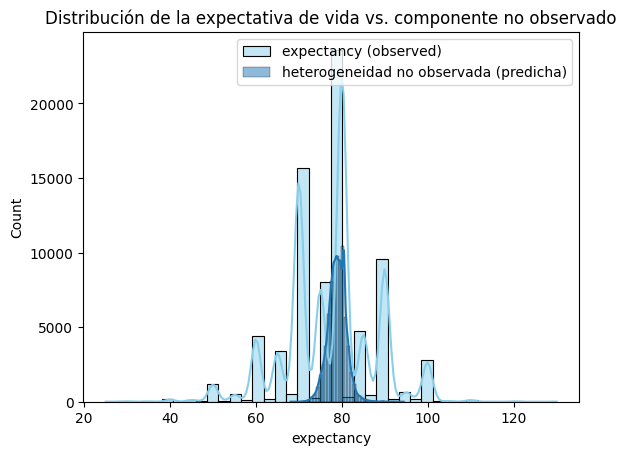

In [69]:
Xpred = X_cre.copy()

cols_to_zero = [
    'edu', 'children', 'exp', 'wage', 'cotizando', 'publicemp',
    'sistema', 'assets', 'exp_sist', 'cronica', 'nocronica', 'mental',
    'status_2.0', 'status_3.0', 'status_4.0', 'status_5.0',
    'situation_3', 'situation_4',
    'occupation_2.0', 'occupation_3.0', 'occupation_4.0',
    'occupation_5.0', 'occupation_6.0', 'occupation_7.0',
    'occupation_8.0', 'occupation_9.0', 'occupation_10.0',
    'region_2.0', 'region_3.0', 'region_4.0', 'region_5.0',
    'region_6.0', 'region_7.0', 'region_8.0', 'region_9.0',
    'region_10.0', 'region_11.0', 'region_12.0', 'region_13.0', 
    'region_14.0', 'region_15.0', 'year_4', 'year_6', 'year_9',
    'year_12', 'year_15'
]

for col in cols_to_zero:
    if col in Xpred.columns:
        Xpred[col] = 0

yhat = cre.predict(Xpred)

# Visualización
sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True, bins=40)
sns.histplot(data=yhat, color="red", label="heterogeneidad no observada (predicha)", kde=True, bins=40)

plt.title("Distribución de la expectativa de vida vs. componente no observado")
plt.legend()
plt.show()

### **8. Usando sus respuestas anteriores, ¿qué modelo prefiere? ¿Qué se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?**

**R**: Considerando los resultados obtenidos, el modelo CRE es el más adecuado para este análisis. Permite separar los efectos entre y dentro de los individuos, incorpora heterogeneidad no observada de forma explícita y ofrece un mayor poder explicativo (R² = 0.50 aprox.). A diferencia del modelo RE clásico, no depende de supuestos fuertes de independencia, y entrega estimaciones más confiables que el modelo de efectos fijos, el cual aunque robusto, pierde eficiencia al descartar toda variabilidad entre personas.

Respecto a la educación, el efecto estimado no es robusto: es negativo y significativo dentro del individuo en el modelo CRE, pero su promedio no lo es, lo que refuerza la idea de que su relación con la expectativa de vida no está bien identificada. Esto puede deberse a colinealidad, selección o problemas de medición.

Por otro lado, variables como la experiencia laboral, activos previsionales, salud mental y empleo informal mostraron efectos consistentes en todos los modelos, lo que las posiciona como determinantes sólidos. Además, las dummies de año fueron crecientes y altamente significativas en todas las especificaciones, lo que indica una tendencia clara, a medida que avanzan las rondas de encuesta, los individuos reportan una expectativa de vida más alta, incluso controlando por edad, salud o nivel socioeconómico. Esto podría reflejar un efecto de percepción, mejoras reales en condiciones de vida, o un cambio en el perfil de quienes permanecen en el panel.

In [70]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 77267             77267             77267
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0361            0.5018            0.5045
R-Squared (Within)              0.0361            0.0268            0.0294
R-Squared (Between)            -0.0030            0.1451            0.1525
R-Squared (Overall)             0.0098            0.0660            0.0741
F-statistic                     47.113            1809.1            1403.7
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    